<a href="https://colab.research.google.com/github/princepatel2004/Edunet-Summer-Intership-/blob/main/%5BDay_6%5D_11_07_2026_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 11-07-2026 Logistic Regression Model

# Import Libraries and Dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
df = pd.read_csv("/waste_classification.csv")
df.head()

,City,Zone,Population_Density,Waste_Collected_Tons,Plastic_Percentage,Organic_Percentage,Paper_Percentage,Glass_Percentage,Recycling_Facility,Composting_Units,Awareness_Score,Waste_Category
0,Pune,West,3971,888,13.0,61,7,19,Yes,NaN,42.0,Mixed
1,Bhubaneswar,East,9813,519,15.0,22,18,45,No,6.0,65.0,Mixed
2,Surat,West,10528,949,46.0,23,8,23,Yes,42.0,42.0,Plastic
3,Bhopal,Central,11093,892,24.0,23,6,47,Yes,20.0,88.0,Mixed
4,Vadodara,West,10358,321,29.0,56,10,5,Yes,NaN,59.0,Mixed


# Information about Dataset

In [5]:
print("Rows and Columns :", df.shape)
df.columns
df.info()

Rows and Columns : (120, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  120 non-null    object 
 1   Zone                  112 non-null    object 
 2   Population_Density    120 non-null    int64  
 3   Waste_Collected_Tons  120 non-null    int64  
 4   Plastic_Percentage    112 non-null    float64
 5   Organic_Percentage    120 non-null    int64  
 6   Paper_Percentage      120 non-null    int64  
 7   Glass_Percentage      120 non-null    int64  
 8   Recycling_Facility    112 non-null    object 
 9   Composting_Units      112 non-null    float64
 10  Awareness_Score       112 non-null    float64
 11  Waste_Category        120 non-null    object 
dtypes: float64(3), int64(5), object(4)
memory usage: 11.4+ KB


# Feature Description

• City – Name of the city.

• Zone – Geographical zone of the city.

• Population_Density – Number of people per square kilometer.

• Waste_Collected_Tons – Daily waste collected.

• Plastic_Percentage – Percentage of plastic waste.

• Organic_Percentage – Percentage of organic waste.

• Paper_Percentage – Percentage of paper waste.

• Glass_Percentage – Percentage of glass
waste.

• Recycling_Facility – Availability of recycling facility.

• Composting_Units – Number of composting units.

• Awareness_Score – Public awareness score regarding waste management.

• Waste_Category – Target variable (Organic, Plastic, Mixed).

# General Observations

• The dataset contains both numerical and categorical features.

• Cities with higher organic waste percentages are more likely to be classified as Organic.

• Higher plastic percentages increase the likelihood of Plastic waste classification.

• Plastic waste percentage is one of the important indicators for classification.

# Check and Handle Missing Values

In [6]:
df.isnull().sum()

,0
City,0
Zone,8
Population_Density,0
Waste_Collected_Tons,0
Plastic_Percentage,8
Organic_Percentage,0
Paper_Percentage,0
Glass_Percentage,0
Recycling_Facility,8
Composting_Units,8


# Missing Value Analysis

The dataset contains missing values in both numerical and categorical columns.

Numerical missing values will be replaced using the mean because it preserves the average of the data.

Categorical missing values will be replaced using the mode because it represents the most common category.


In [7]:
numerical_columns = [
    "Plastic_Percentage",
    "Composting_Units",
    "Awareness_Score"
]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

In [8]:
df["Zone"] = df["Zone"].fillna(df["Zone"].mode()[0])

df["Recycling_Facility"] = df["Recycling_Facility"].fillna(
    df["Recycling_Facility"].mode()[0]
)
df.isnull().sum()

,0
City,0
Zone,0
Population_Density,0
Waste_Collected_Tons,0
Plastic_Percentage,0
Organic_Percentage,0
Paper_Percentage,0
Glass_Percentage,0
Recycling_Facility,0
Composting_Units,0


# Why Mean and Mode?

• Mean preserves the average value of numerical data and minimizes the impact of missing values.

• Mode is appropriate for categorical variables because it replaces missing entries with the most frequently occurring category.


# Feature Engineering

A new feature called Recyclable_Percentage is created.

It represents the combined percentage of Plastic, Paper, and Glass waste.


In [9]:
df["Recyclable_Percentage"] = (
    df["Plastic_Percentage"] +
    df["Paper_Percentage"] +
    df["Glass_Percentage"]
)
df.head()

,City,Zone,Population_Density,Waste_Collected_Tons,Plastic_Percentage,Organic_Percentage,Paper_Percentage,Glass_Percentage,Recycling_Facility,Composting_Units,Awareness_Score,Waste_Category,Recyclable_Percentage
0,Pune,West,3971,888,13.0,61,7,19,Yes,29.053571,42.0,Mixed,39.0
1,Bhubaneswar,East,9813,519,15.0,22,18,45,No,6.000000,65.0,Mixed,78.0
2,Surat,West,10528,949,46.0,23,8,23,Yes,42.000000,42.0,Plastic,77.0
3,Bhopal,Central,11093,892,24.0,23,6,47,Yes,20.000000,88.0,Mixed,77.0
4,Vadodara,West,10358,321,29.0,56,10,5,Yes,29.053571,59.0,Mixed,44.0


# Relationship Between Features

• Population density influences the amount of waste collected.

• Higher organic waste percentage increases the likelihood of Organic waste classification.

• Higher plastic waste percentage increases the likelihood of Plastic waste classification.

• Waste composition directly affects the predicted waste category.

# Seaborn Visualizations

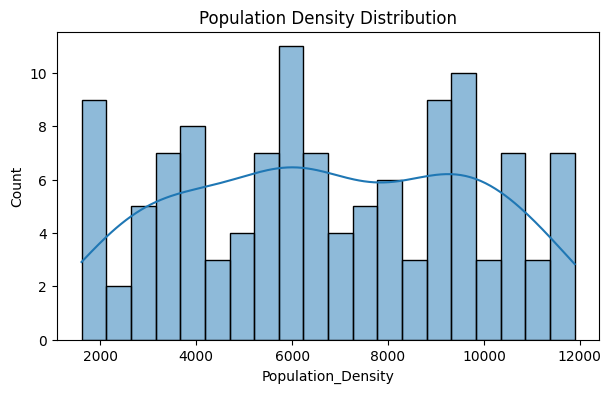

In [10]:
# Distribution of Population Density using Histogram
plt.figure(figsize=(7,4))

sns.histplot(df["Population_Density"], bins=20, kde=True)

plt.title("Population Density Distribution")

plt.show()

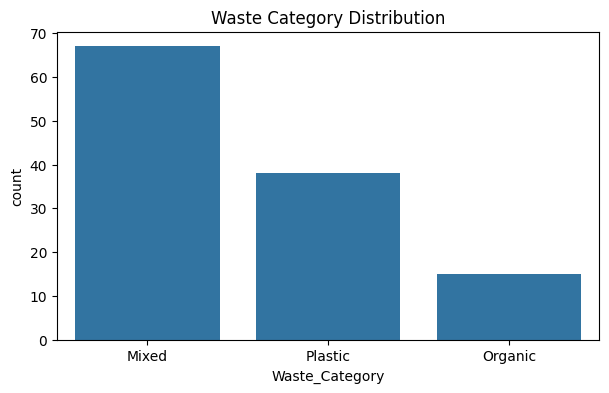

In [11]:
# Waste Category Count
plt.figure(figsize=(7,4))

sns.countplot(data=df, x="Waste_Category")

plt.title("Waste Category Distribution")

plt.show()

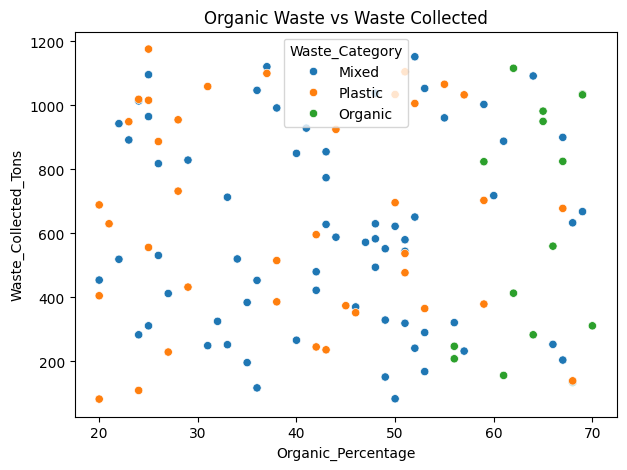

In [12]:
#Scatter Plot
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Organic_Percentage",
    y="Waste_Collected_Tons",
    hue="Waste_Category"
)

plt.title("Organic Waste vs Waste Collected")

plt.show()

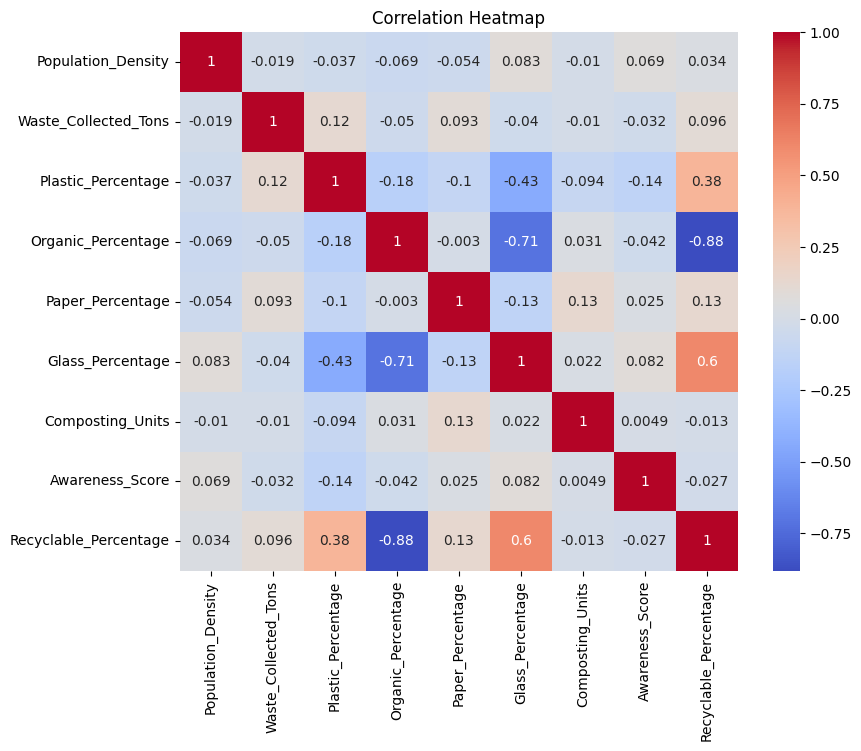

In [13]:
# Correlation Heatmap
plt.figure(figsize=(9,7))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Label Encoding

Label Encoding converts categorical text into numerical labels.

The City, Zone, Recycling_Facility, and Waste_Category columns are converted into numerical values using Label Encoding.


In [15]:
from sklearn.preprocessing import LabelEncoder

le_city = LabelEncoder()
le_zone = LabelEncoder()
le_recycle = LabelEncoder()
le_target = LabelEncoder()

df["City"] = le_city.fit_transform(df["City"])
df["Zone"] = le_zone.fit_transform(df["Zone"])
df["Recycling_Facility"] = le_recycle.fit_transform(df["Recycling_Facility"])
df["Waste_Category"] = le_target.fit_transform(df["Waste_Category"])
df.head()

,City,Zone,Population_Density,Waste_Collected_Tons,Plastic_Percentage,Organic_Percentage,Paper_Percentage,Glass_Percentage,Recycling_Facility,Composting_Units,Awareness_Score,Waste_Category,Recyclable_Percentage
0,11,4,3971,888,13.0,61,7,19,1,29.053571,42.0,0,39.0
1,3,1,9813,519,15.0,22,18,45,0,6.000000,65.0,0,78.0
2,13,4,10528,949,46.0,23,8,23,1,42.000000,42.0,2,77.0
3,2,0,11093,892,24.0,23,6,47,1,20.000000,88.0,0,77.0
4,14,4,10358,321,29.0,56,10,5,1,29.053571,59.0,0,44.0


# Scaling Numerical Features

The numerical features have different ranges.

StandardScaler standardizes numerical features so that each has a mean of 0 and a standard deviation of 1.

This improves model stability and model performance.

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
target = "Waste_Category"

numerical_cols = [
    "Population_Density",
    "Waste_Collected_Tons",
    "Plastic_Percentage",
    "Organic_Percentage",
    "Paper_Percentage",
    "Glass_Percentage",
    "Composting_Units",
    "Awareness_Score",
    "Recyclable_Percentage"
]

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,City,Zone,Population_Density,Waste_Collected_Tons,Plastic_Percentage,Organic_Percentage,Paper_Percentage,Glass_Percentage,Recycling_Facility,Composting_Units,Awareness_Score,Waste_Category,Recyclable_Percentage
0,11,4,-0.953344,0.860436,-1.386617,1.086586,-1.211450,0.197696,1,-2.219446e-16,-1.430702,0,-1.433586
1,3,1,1.034859,-0.295865,-1.207492,-1.537368,1.178855,2.162066,0,-1.440200e+00,-0.080212,0,1.598324
2,13,4,1.278194,1.051586,1.568940,-1.470087,-0.994149,0.499907,1,8.087875e-01,-1.430702,2,1.520582
3,2,0,1.470480,0.872971,-0.401431,-1.470087,-1.428750,2.313171,1,-5.655935e-01,1.270279,0,1.520582
4,14,4,1.220338,-0.916319,0.046380,0.750182,-0.559549,-0.860041,1,-2.219446e-16,-0.432513,0,-1.044880


# Train-Test Split

The dataset is divided into training and testing sets.

Training Set (80%)
Used to train the Logistic Regression model.

Testing Set (20%)
Used to evaluate the model on unseen data.

The target variable is Waste_Category.

In [17]:
# Features (Independent Variables)
X = df.drop("Waste_Category", axis=1)

# Target (Dependent Variable)
y = df["Waste_Category"]

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (96, 12)
Testing Shape : (24, 12)


# Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification problems.

It predicts the probability that a data point belongs to a particular class.

In this project, the model classifies waste into:

• Organic

• Plastic

• Mixed

In [19]:
# create model
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

The Logistic Regression model has learned the relationship between the waste management features and the waste category using the training dataset.

In [20]:
# predict
y_pred = model.predict(X_test)

In [21]:
# compare actual and predicted values
comparison = pd.DataFrame({
    "Actual": le_target.inverse_transform(y_test),
    "Predicted": le_target.inverse_transform(y_pred)
})

comparison.head(10)

,Actual,Predicted
0,2,2
1,0,2
2,2,2
3,0,0
4,0,2
5,2,2
6,0,0
7,2,2
8,0,0
9,1,0


# Model Evaluation

The Logistic Regression model is evaluated using:

• Accuracy

• Confusion Matrix

• Classification Report


In [22]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.8333333333333334


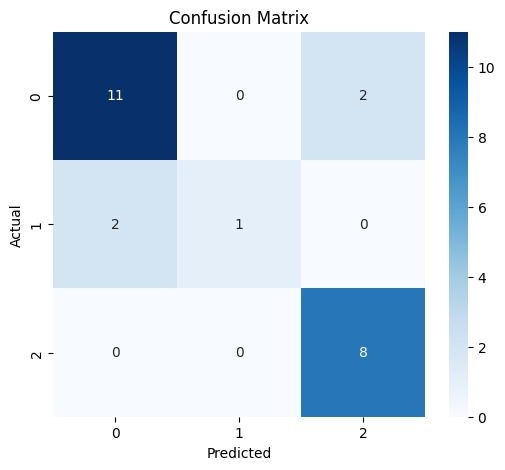

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le_target.classes_,
    yticklabels=le_target.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(c) for c in le_target.classes_]
))

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       1.00      0.33      0.50         3
           2       0.80      1.00      0.89         8

    accuracy                           0.83        24
   macro avg       0.88      0.73      0.75        24
weighted avg       0.85      0.83      0.82        24



# Understanding Classification Metrics

• Accuracy -
Measures the overall percentage of correctly classified samples.

Higher accuracy indicates better overall performance.


• Precision -
Measures how many predicted samples of a class are actually correct.

Higher precision means fewer false positive predictions.


• Recall -
Measures how many actual samples of a class were correctly identified.

Higher recall means fewer false negatives.


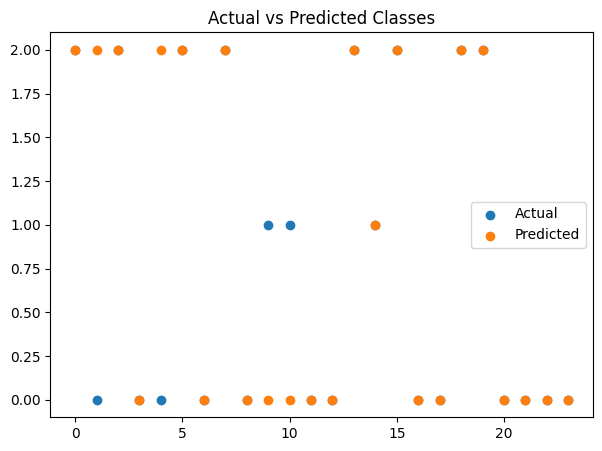

In [26]:
# compare actual and predicted values
plt.figure(figsize=(7,5))

plt.scatter(range(len(y_test)), y_test, label="Actual")

plt.scatter(range(len(y_pred)), y_pred, label="Predicted")

plt.legend()

plt.title("Actual vs Predicted Classes")

plt.show()

# Observation

The scatter plot compares the actual and predicted classes.

The greater the overlap between the two sets of points, the better the model's classification performance.

# Final Insights

• Population density influences the amount of waste generated.

• Organic waste percentage is an important indicator for identifying Organic waste.

• Plastic percentage strongly contributes to Plastic waste classification.


• Feature engineering created a useful recyclable waste feature.

• Missing values were successfully handled using mean and mode imputation.

• Label Encoding converted categorical features into numerical values.

• StandardScaler standardized numerical features for improved model training.

• The Logistic Regression model successfully classified waste into Organic, Plastic, and Mixed categories.

# Conclusion

In this task, a sustainability-based waste management dataset was analyzed using Exploratory Data Analysis (EDA) and preprocessing techniques.

Missing values were handled, a new feature was engineered, categorical variables were encoded using Label Encoding, and numerical variables were standardized using StandardScaler.

A Logistic Regression model was trained to classify waste into Organic, Plastic, and Mixed categories.

The model was evaluated using Accuracy, Confusion Matrix, Precision, Recall, and F1-Score.

The complete workflow demonstrates the application of machine learning for sustainable waste classification and environmental data analysis.